<a href="https://colab.research.google.com/github/Dima-BR/machine-learning-projects/blob/main/hr_analysis_employee_attrition_performance_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HR Employee Attrition

## Import Libraries

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# For modling
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE


# pd.options.display.float_format = '{:20.2f}'.format
pd.set_option('display.max_columns', 999)

import seaborn as sns; sns.set_theme()
# sns.palplot(sns.cubehelix_palette())

sns.set_theme(style="whitegrid")
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
my_palette = sns.cubehelix_palette(start=2, rot=0.2, dark=0.3, light=0.8, reverse=True)
sns.set_palette(my_palette)

import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [5]:
# df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/datasets/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# EDA

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [7]:
df.shape

(1470, 35)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [12]:
df.describe().T.style.background_gradient(cmap='Purples')


,count,mean,std,min,25%,50%,75%,max
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1470.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1470.000000,1024.865306,602.024335,1.000000,491.250000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1470.000000,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000000


In [13]:
df.describe(include='O')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [14]:
cols = ['Attrition', 'Department', 'JobRole', 'MaritalStatus', 'Over18',
        'BusinessTravel', 'OverTime', 'Gender', 'EducationField']

for col in cols:
    styled_df = df[col].value_counts().to_frame().T.style.background_gradient(cmap='Purples', axis=1)
    display(styled_df)

Attrition,No,Yes
count,1233,237


Department,Research & Development,Sales,Human Resources
count,961,446,63


JobRole,Sales Executive,Research Scientist,Laboratory Technician,Manufacturing Director,Healthcare Representative,Manager,Sales Representative,Research Director,Human Resources
count,326,292,259,145,131,102,83,80,52


MaritalStatus,Married,Single,Divorced
count,673,470,327


Over18,Y
count,1470


BusinessTravel,Travel_Rarely,Travel_Frequently,Non-Travel
count,1043,277,150


OverTime,No,Yes
count,1054,416


Gender,Male,Female
count,882,588


EducationField,Life Sciences,Medical,Marketing,Technical Degree,Other,Human Resources
count,606,464,159,132,82,27


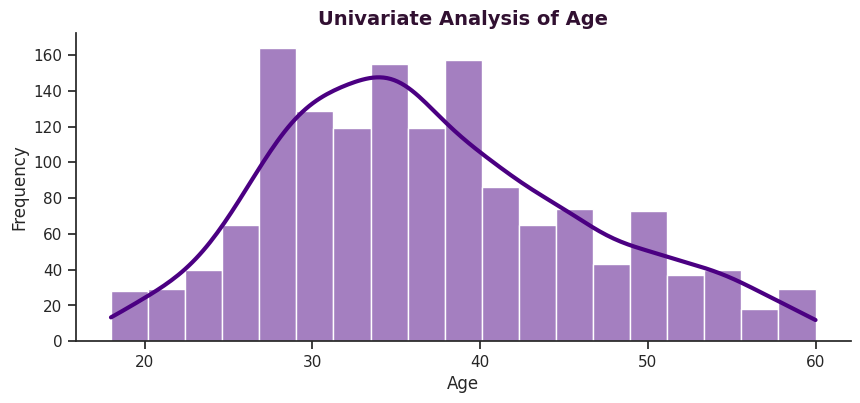

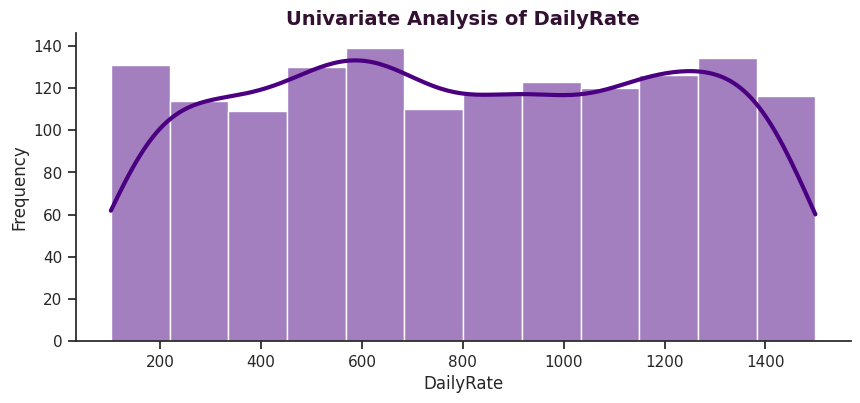

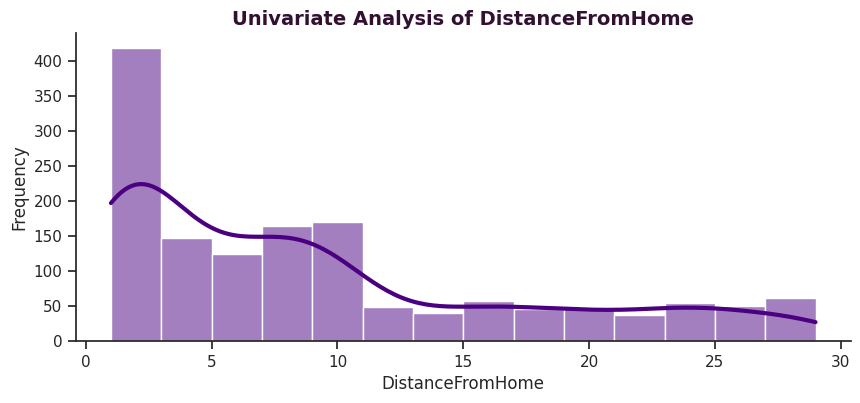

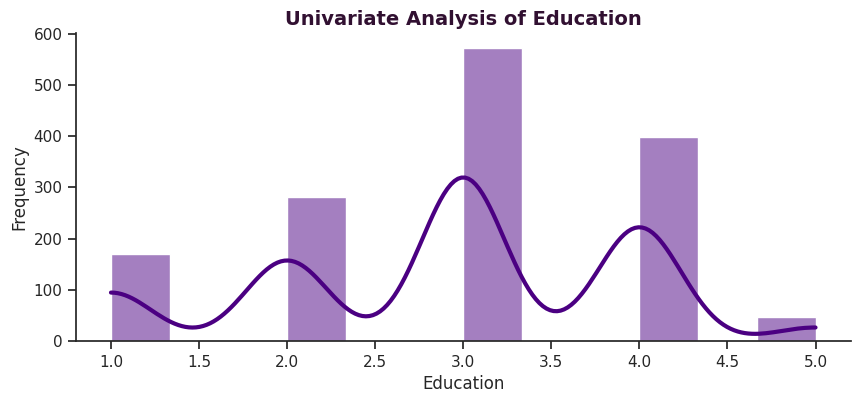

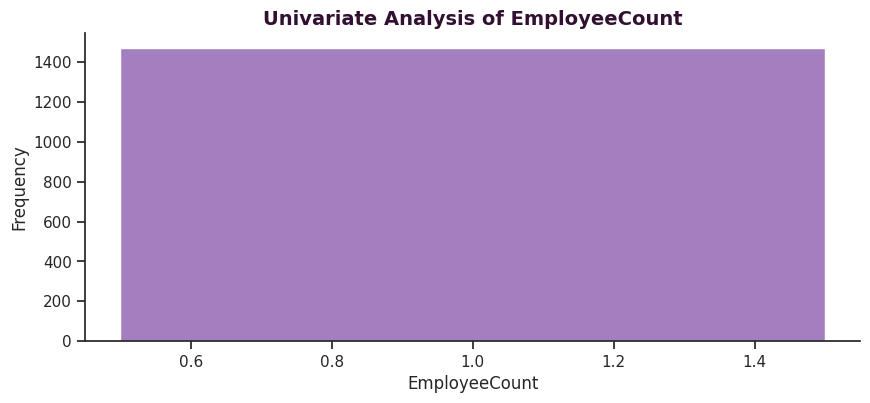

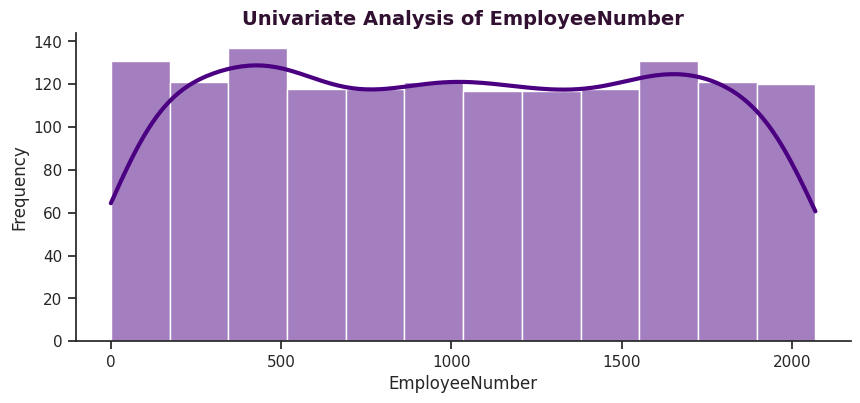

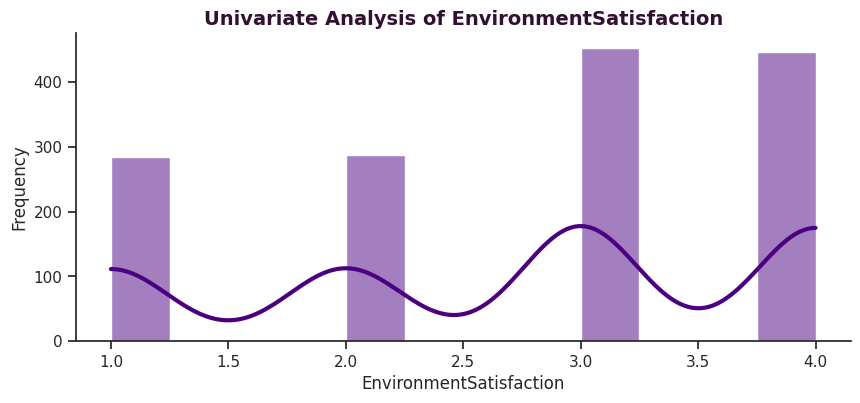

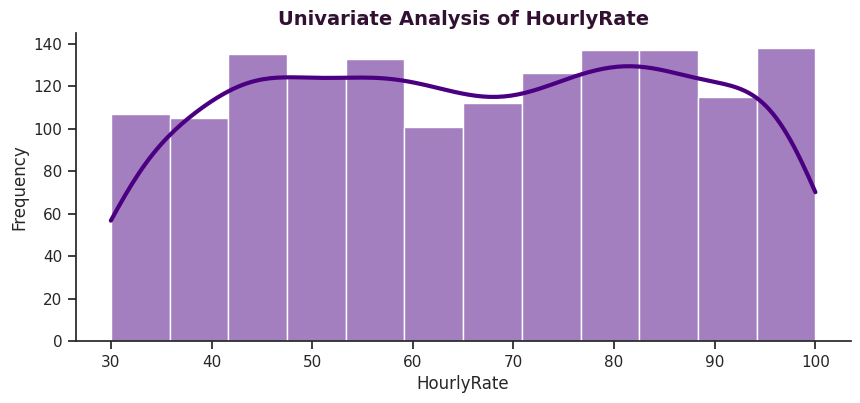

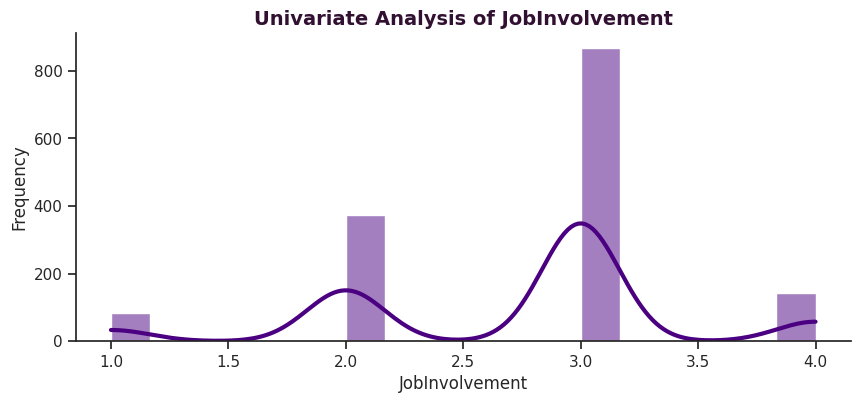

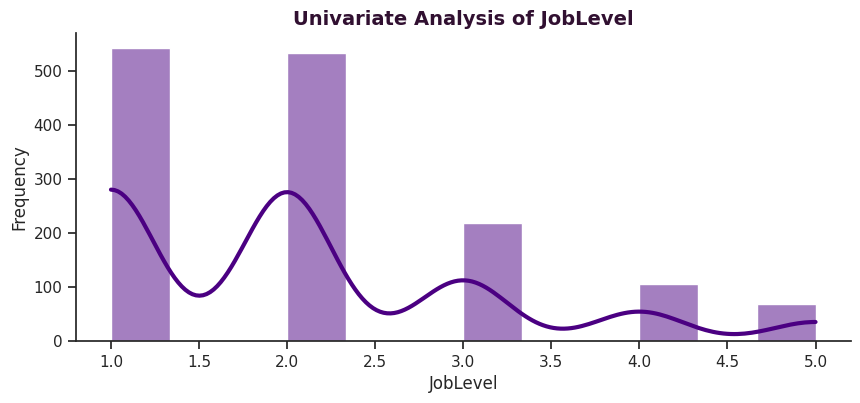

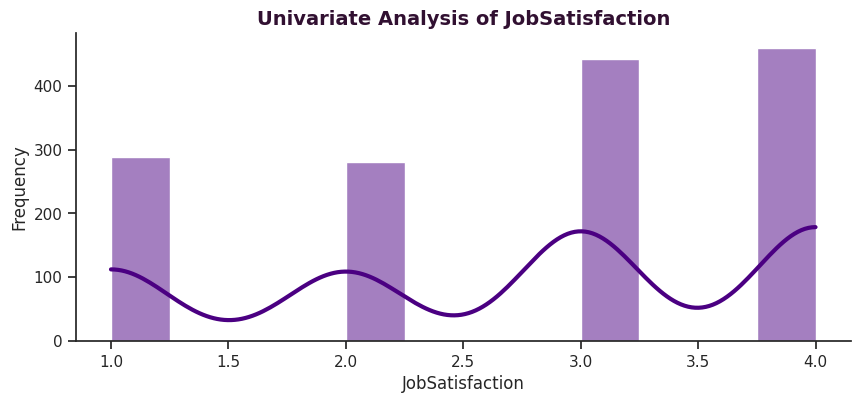

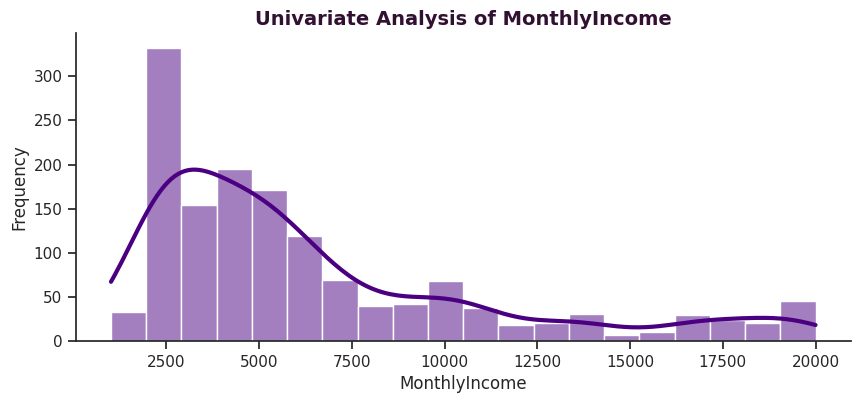

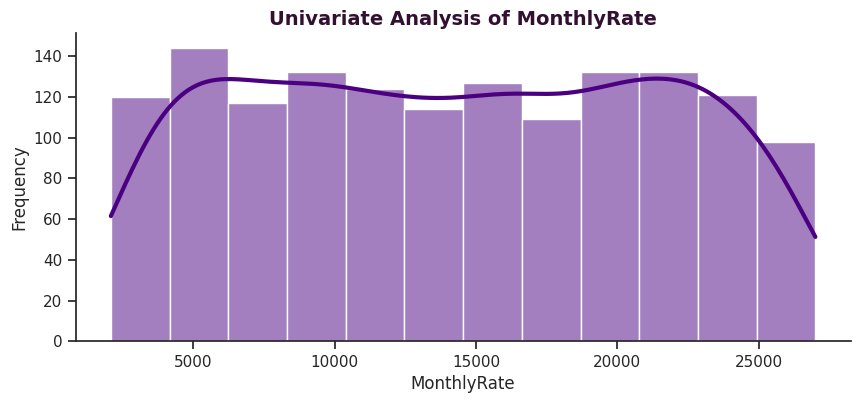

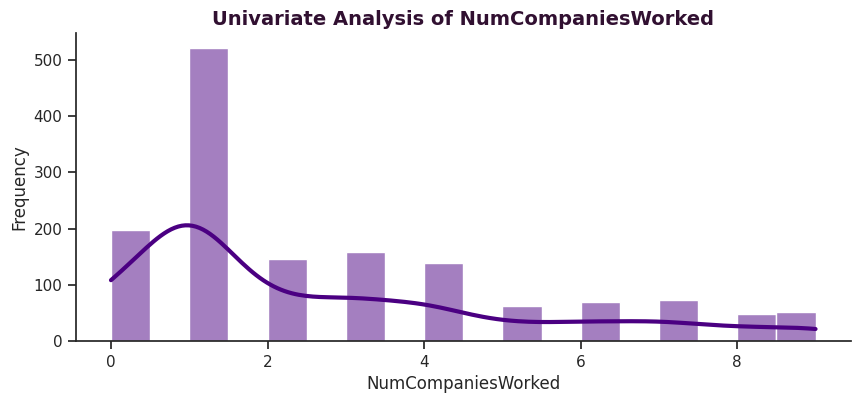

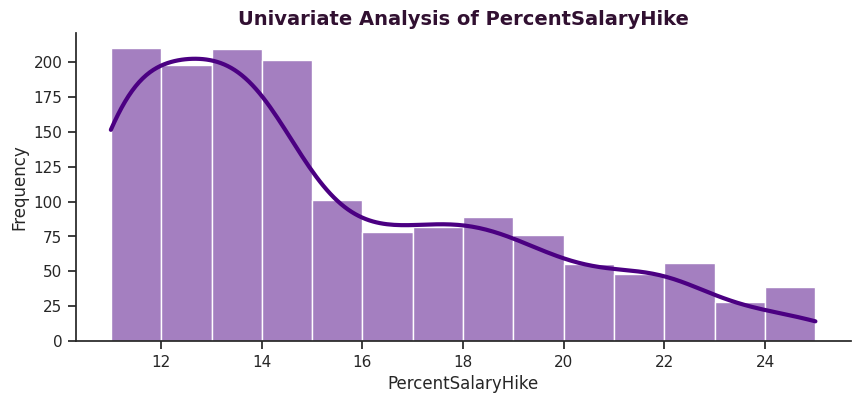

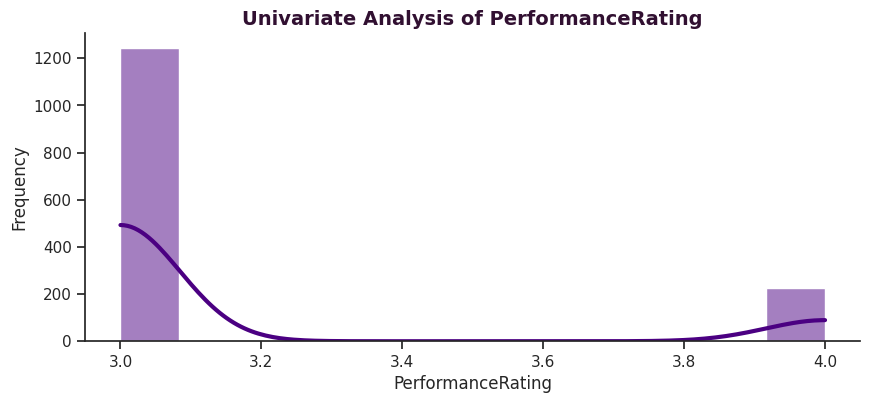

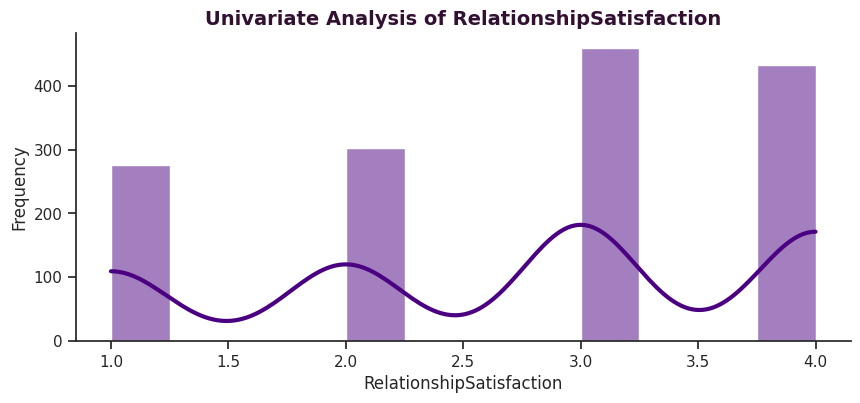

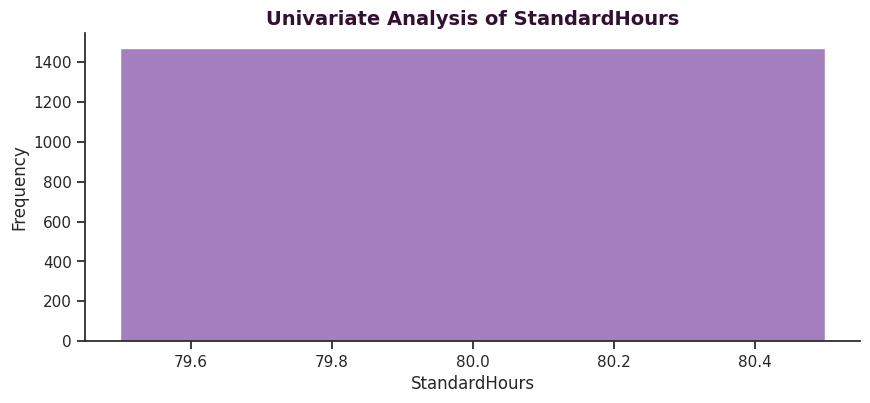

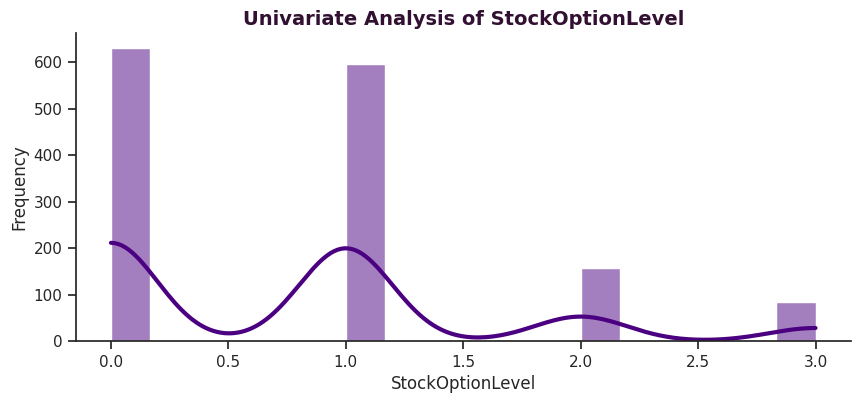

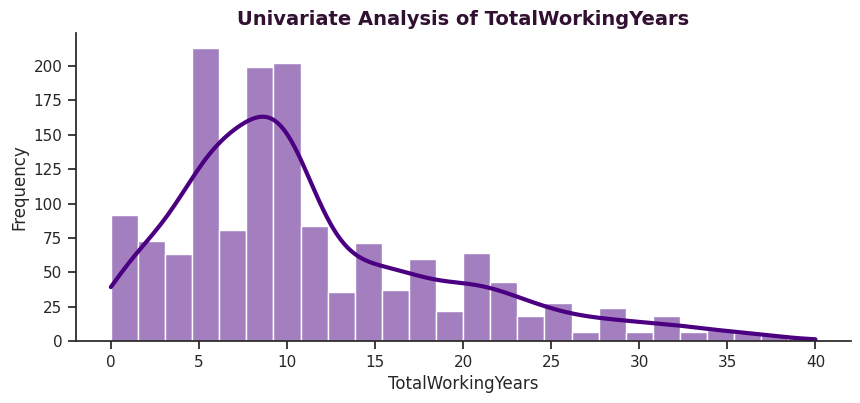

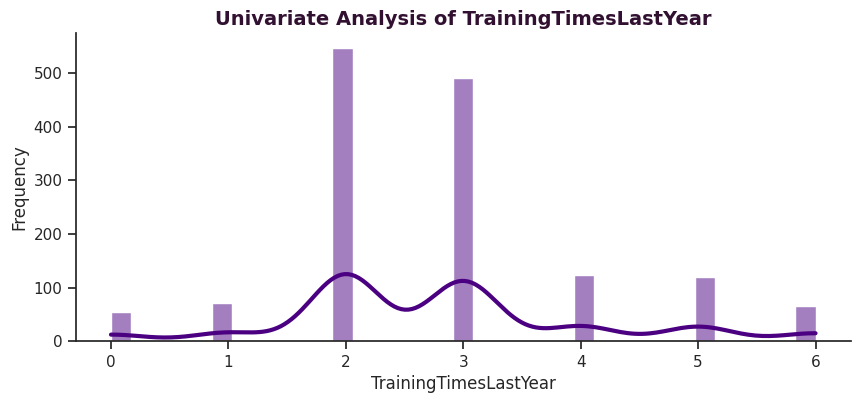

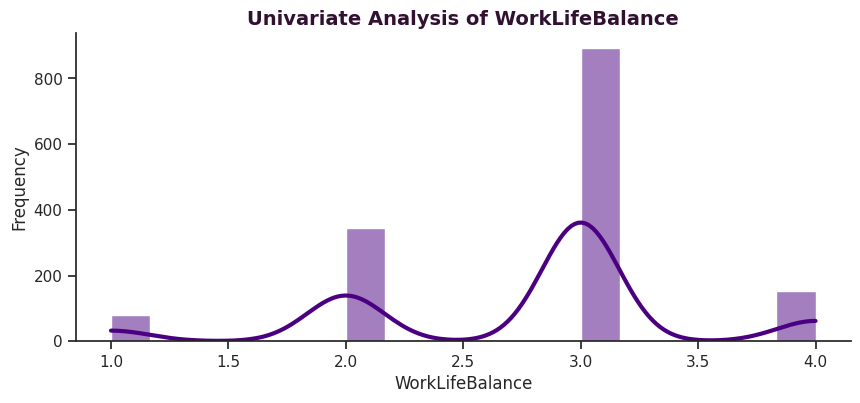

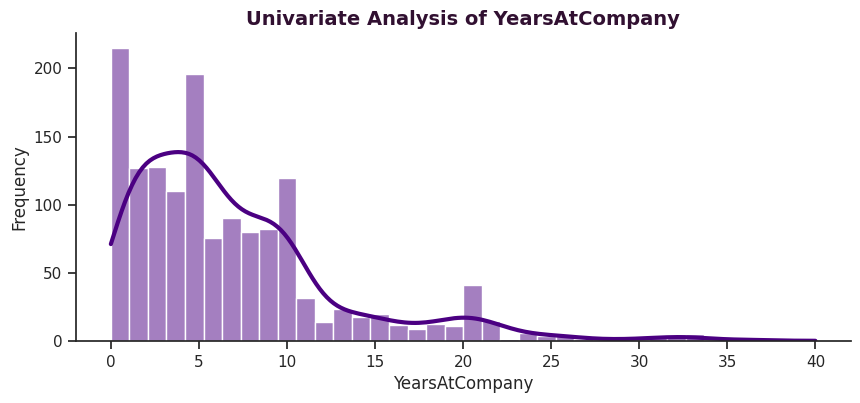

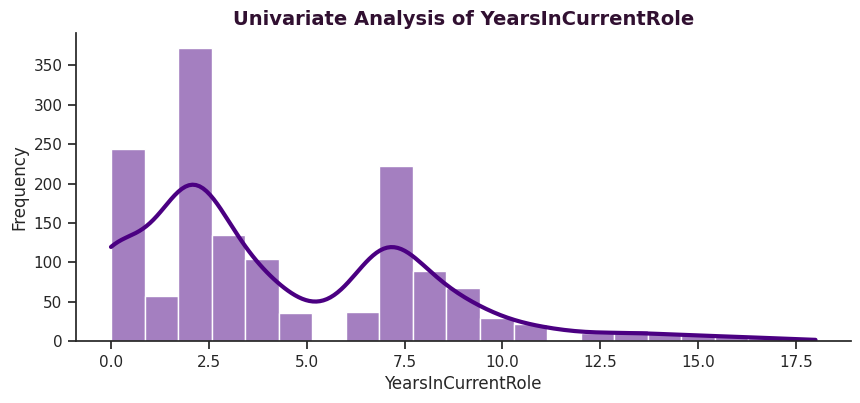

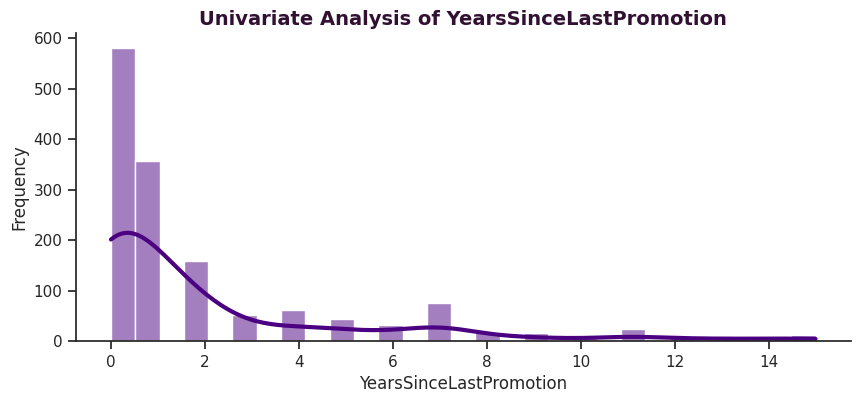

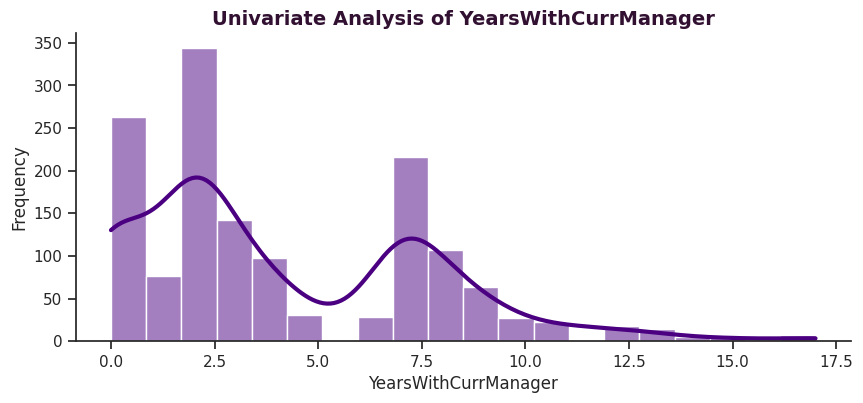

In [15]:
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(10, 4))

    sns.histplot(df[col], kde=True, color='#4B0082', line_kws={'lw': 3})

    plt.title(f'Univariate Analysis of {col}', fontsize=14, fontweight='bold', color='#311031')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    sns.despine()
    plt.show()

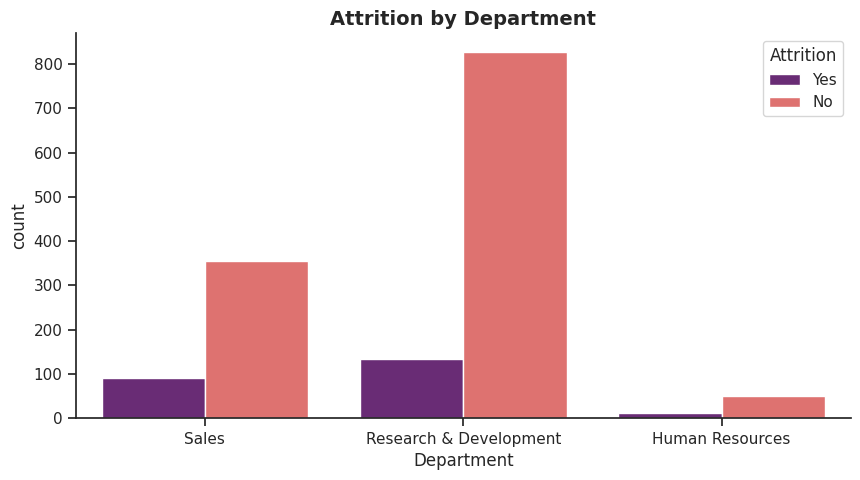

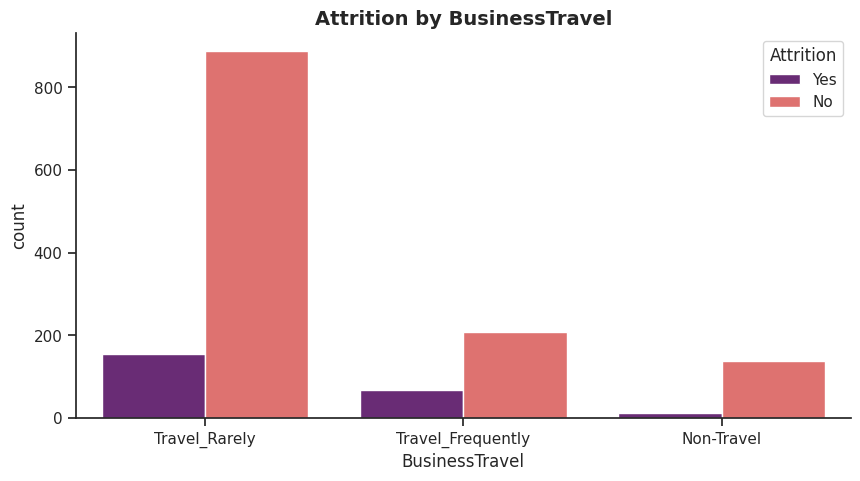

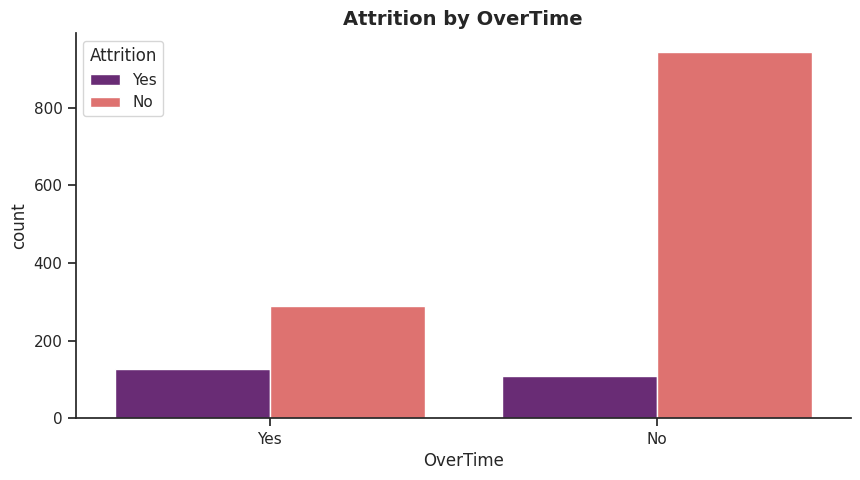

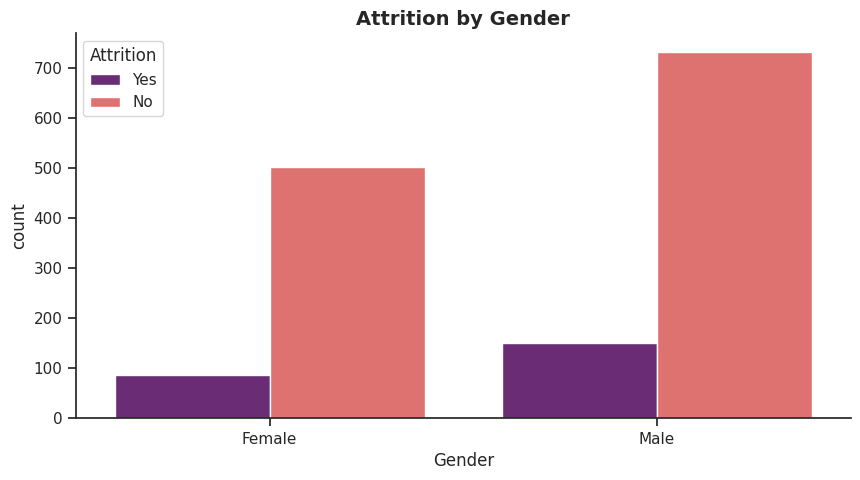

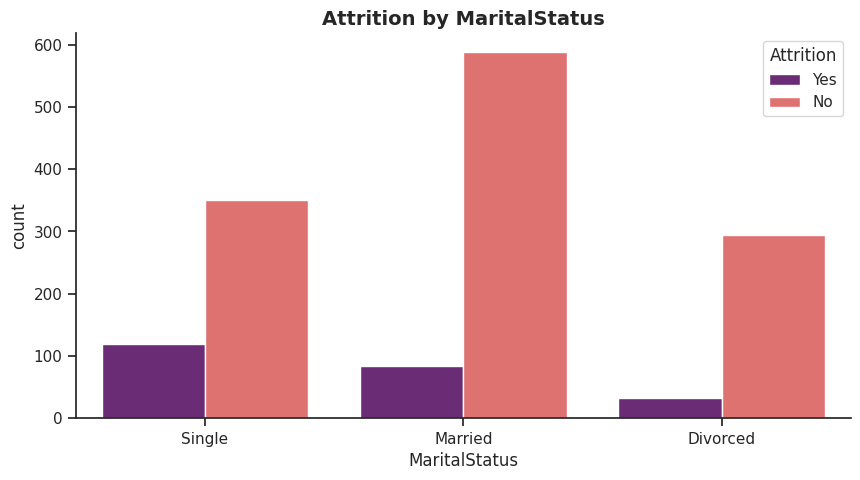

In [16]:
features = ['Department', 'BusinessTravel', 'OverTime', 'Gender', 'MaritalStatus']

for col in features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, hue='Attrition', palette='magma')
    plt.title(f'Attrition by {col}', fontsize=14, fontweight='bold')
    sns.despine()
    plt.show()

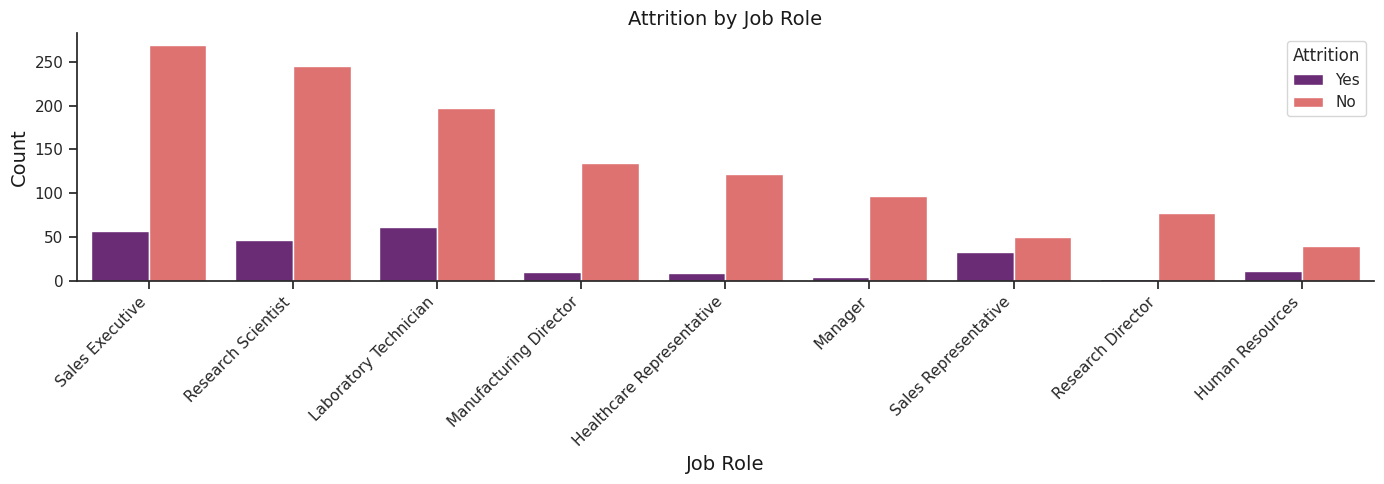

In [17]:
plt.figure(figsize=(14, 5))

sns.countplot(data=df, x='JobRole', hue='Attrition', palette='magma')

plt.title('Attrition by Job Role', fontsize=14, c='k')
plt.xlabel('Job Role', fontsize=14, c='k')
plt.ylabel('Count', fontsize=14, c='k')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [18]:
fig = px.box(df, x='Attrition', y='MonthlyIncome',
             title='Monthly Income Distribution by Attrition Status',
             color_discrete_sequence=['darkviolet'])
fig.show()

***Monthly Income Distribution by Attrition Status***

In [19]:
fig = px.box(df, x='Attrition', y='MonthlyIncome',
             title='Monthly Income Distribution by Attrition Status',
             color_discrete_sequence=['darkviolet'])
fig.show()

**Attrition by Years At Company**

In [20]:
purple_colors = {1: '#311031', 0: '#9370DB'}

fig = px.strip(df, x='Attrition', y='YearsAtCompany',
               color='Attrition',
               title='Years At Company vs Attrition (Individual Points)',
               color_discrete_map=purple_colors)

fig.update_layout(plot_bgcolor='white')
fig.show()

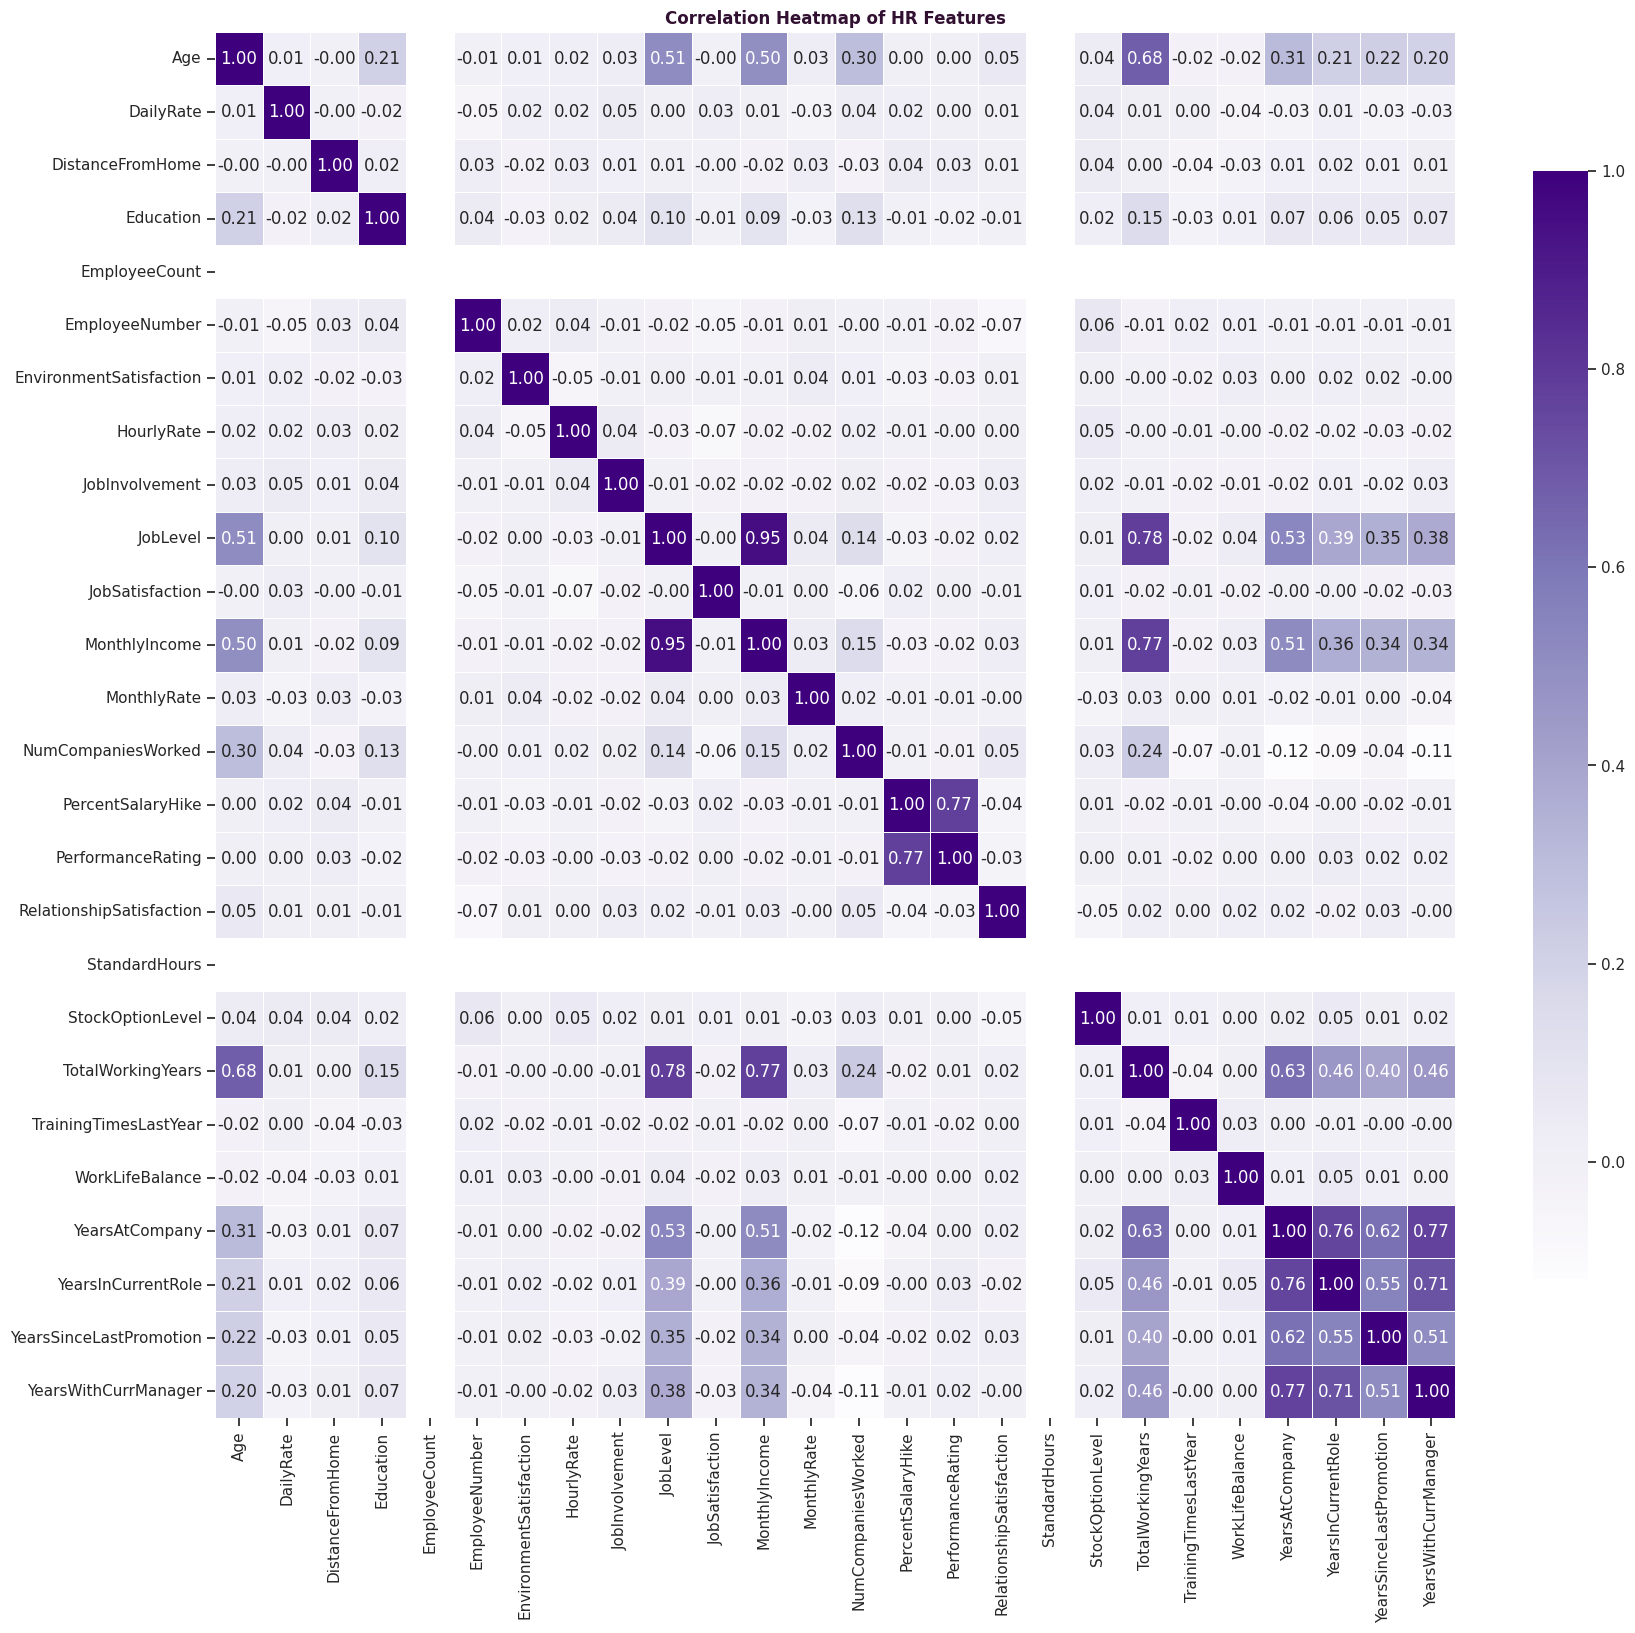

In [24]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(20, 18))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='Purples',
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of HR Features', fontsize=12, fontweight='bold', color='#311031')
plt.show()

### **Initial Data Observations & Pre-processing Plan**

**Dataset Shape:** (1470, 35)

* **No Missing Values:** The dataset is complete with no null entries.
* **No Duplicates:** There are no redundant rows identified.
* **Feature Removal:** Drop `'EmployeeCount'`, `'StandardHours'`, `'Over18'`, and `'EmployeeNumber'` as they are constant values or unique identifiers (ID columns).
* **Target Encoding:** Transform the `'Attrition'` column into a numerical format.
* **Binary Encoding:** Apply encoding to binary categorical features such as `'Gender'` and `'OverTime'`.
* **Nominal Encoding:** Perform **One-Hot Encoding** for multi-level nominal categorical variables.

---

# Cleaning Data & Pre-processing

***Drop constant and ID columns***

In [25]:
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], inplace=True, errors='ignore')

***Target Encoding***

In [26]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [27]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

corr = df[numeric_cols].corr()['Attrition'].sort_values(ascending=False)

fig = px.bar(x=corr.values, y=corr.index, orientation='h',
             title='Correlation of Features with Attrition',
             labels={'x': 'Correlation Coefficient', 'y': 'Feature'},
             color=corr.values,
             color_continuous_scale=['#E6E6FA', '#311031'])

fig.update_layout(plot_bgcolor='white', yaxis={'categoryorder':'total ascending'})
fig.show()

### Encoding categorical column

In [28]:
# Encode binary
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# df['OverTime'] = df['OverTime'].replace({'Yes': 1, 'No': 0})
# df['Gender'] = df['Gender'].replace({'Male': 1, 'Female': 0})

# One-hot encode
df = pd.get_dummies(data=df, columns=['BusinessTravel', 'Department', 'EducationField',
                                       'JobRole', 'MaritalStatus'], drop_first=True)

In [29]:
df.shape

(1470, 45)

In [30]:
df.head()


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False


## Target & Features Split

In [31]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

## Target Distrubution

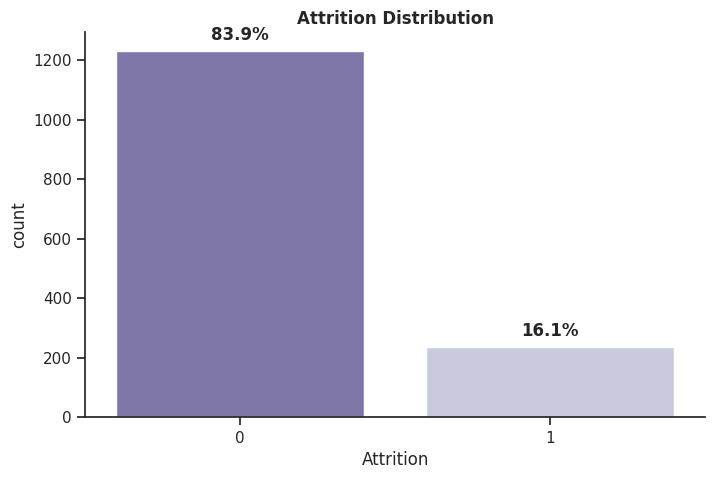

In [32]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Attrition', hue='Attrition', palette="Purples_r", legend=False)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.title('Attrition Distribution', fontweight='bold')

plt.show()

**The dataset is imbalanced (83.9% vs 16.1%), which may bias the model towards the majority class; therefore, I will use techniques like SMOTE to balance the classes and improve prediction accuracy.**

## Handle Imbalance Using SMOTE

In [33]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f'Before SMOTE: {y.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_resampled).value_counts().to_dict()}')
print(f'Resampled dataset shape: {X_resampled.shape}')

Before SMOTE: {0: 1233, 1: 237}
After SMOTE:  {1: 1233, 0: 1233}
Resampled dataset shape: (2466, 44)


## Train & Test Split

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print('x_train shape:', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape: ', y_test.shape)

# Verify class balance preserved
print(f'\ny_train distribution:\n{y_train.value_counts()}')
print(f'\ny_test distribution:\n{y_test.value_counts()}')

x_train shape: (1972, 44)
x_test shape:  (494, 44)
y_train shape: (1972,)
y_test shape:  (494,)

y_train distribution:
Attrition
1    986
0    986
Name: count, dtype: int64

y_test distribution:
Attrition
1    247
0    247
Name: count, dtype: int64


## Feature Scaling

In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=scaler.get_feature_names_out())
x_test_scaled = pd.DataFrame(x_test_scaled, columns=scaler.get_feature_names_out())

print('x_train_scaled shape:', x_train_scaled.shape)
print('x_test_scaled shape: ', x_test_scaled.shape)

x_train_scaled shape: (1972, 44)
x_test_scaled shape:  (494, 44)


In [36]:
x_train_scaled

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,-1.061745,-0.298354,1.439836,-0.746624,0.472626,-1.018425,-0.250127,0.639624,-0.832796,-0.430612,-0.826986,-1.037043,-1.107584,1.558706,-0.591702,-0.336890,0.459731,0.536457,-0.924652,0.361907,0.533101,-0.525885,-0.762721,-0.661788,-0.443211,-0.424419,0.819260,-1.032999,-0.582035,-0.655760,-0.300175,1.931066,-0.188982,-0.259036,-0.142042,-0.402555,-0.209615,-0.246547,-0.181663,-0.404255,-0.493335,-0.206965,1.405119,-0.650230
1,-0.504508,1.302570,-0.110736,-1.767667,0.472626,0.981908,-1.710063,0.639624,1.137539,-0.430612,1.158930,-0.009337,-0.682568,-0.641558,2.875007,2.968324,1.416048,0.536457,0.425125,2.866047,1.907316,1.192784,1.347218,-0.661788,1.364468,-0.424419,0.819260,0.968056,-0.582035,1.524947,-0.300175,-0.517849,-0.188982,-0.259036,-0.142042,-0.402555,-0.209615,4.056024,-0.181663,-0.404255,-0.493335,-0.206965,-0.711684,-0.650230
2,-0.393061,0.103875,-0.627594,-0.746624,1.414059,-1.018425,0.062717,-0.749516,0.152371,-0.430612,0.030139,0.163257,0.167463,-0.641558,-0.880594,-0.336890,-1.452904,0.536457,0.290147,-0.472807,0.533101,0.161583,-0.762721,0.006781,0.460628,-0.424419,0.819260,0.968056,-0.582035,1.524947,-0.300175,-0.517849,-0.188982,-0.259036,-0.142042,-0.402555,-0.209615,-0.246547,-0.181663,2.473688,-0.493335,-0.206965,1.405119,-0.650230
3,-0.170166,-1.281284,-1.015237,0.274418,1.414059,0.981908,-0.302267,0.639624,0.152371,1.419425,0.123850,0.592917,-0.682568,-0.641558,2.008329,2.968324,0.459731,-0.736579,-0.519719,2.031334,0.533101,-0.010284,0.442959,-0.327503,0.159348,-0.424419,0.819260,-1.032999,1.718111,-0.655760,-0.300175,-0.517849,5.291503,-0.259036,-0.142042,-0.402555,-0.209615,-0.246547,-0.181663,-0.404255,2.027020,-0.206965,-0.711684,1.537917
4,-0.615956,-0.756522,2.215122,2.316503,0.472626,0.981908,1.731215,0.639624,0.152371,1.419425,-0.105695,1.517487,1.867525,-0.641558,2.297222,2.968324,1.416048,0.536457,0.020192,-0.472807,-0.841115,0.333450,1.045798,1.678201,1.063188,-0.424419,0.819260,-1.032999,1.718111,-0.655760,3.331390,-0.517849,-0.188982,-0.259036,-0.142042,-0.402555,-0.209615,-0.246547,-0.181663,-0.404255,2.027020,-0.206965,-0.711684,-0.650230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967,-1.061745,1.459732,1.439836,0.274418,-1.410239,-1.018425,-1.032235,-0.749516,-0.832796,-0.430612,-0.747237,0.700683,-0.682568,-0.641558,0.274975,-0.336890,-0.496587,-0.736579,-1.194607,-2.142234,-0.841115,-0.869619,-1.064140,-0.661788,-1.045771,-0.424419,-1.220614,-1.032999,-0.582035,-0.655760,-0.300175,-0.517849,-0.188982,-0.259036,-0.142042,-0.402555,-0.209615,-0.246547,-0.181663,-0.404255,-0.493335,-0.206965,-0.711684,-0.650230
1968,-0.281614,-0.527438,0.018478,-1.767667,-1.410239,0.981908,-1.449360,-2.138656,-0.832796,1.419425,-0.554372,-1.088259,1.867525,-0.641558,-0.591702,-0.336890,-1.452904,3.082530,-0.249763,-0.472807,0.533101,-0.354018,-0.159881,-0.327503,-0.141932,-0.424419,0.819260,0.968056,-0.582035,-0.655760,-0.300175,1.931066,-0.188982,-0.259036,-0.142042,2.484131,-0.209615,-0.246547,-0.

# Modeling

In [37]:
from sklearn.model_selection import KFold
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

In [38]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


def applyModel(model, model_name):
    scores = cross_val_score(model, x_train_scaled, y_train, cv=k_fold, scoring='accuracy')
    cv_accuracy = round(np.mean(scores) * 100, 2)

    model.fit(x_train_scaled, y_train)
    predictions = model.predict(x_test_scaled)

    print(f" {'='*10} {model_name} {'='*10}")
    print(f"CV Accuracy: {cv_accuracy}%")
    print("-" * 30)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    print("\n")

    return cv_accuracy

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [40]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Gaussian NB": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.01, random_state=42)
}

results = {}
for name, model in models.items():
    results[name] = applyModel(model, name)

 ========== Logistic Regression ==========
CV Accuracy: 90.57%
------------------------------
Confusion Matrix:
[[226  21]
 [ 28 219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.91      0.89      0.90       247

    accuracy                           0.90       494
   macro avg       0.90      0.90      0.90       494
weighted avg       0.90      0.90      0.90       494



 ========== Gaussian NB ==========
CV Accuracy: 72.77%
------------------------------
Confusion Matrix:
[[137 110]
 [ 29 218]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.55      0.66       247
           1       0.66      0.88      0.76       247

    accuracy                           0.72       494
   macro avg       0.74      0.72      0.71       494
weighted avg       0.74      0.72      0.71       494



 ========== KNN ==========
CV Ac

In [42]:
results_list = []

def applyModel(model, model_name):
    scores = cross_val_score(model, x_train_scaled, y_train, cv=k_fold, scoring='accuracy')
    cv_accuracy = round(np.mean(scores) * 100, 2)

    model.fit(x_train_scaled, y_train)
    predictions = model.predict(x_test_scaled)

    test_accuracy = round(accuracy_score(y_test, predictions) * 100, 2)

    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    results_list.append({
        'Model Name': model_name,
        'CV Accuracy (%)': cv_accuracy,
        'Test Accuracy (%)': test_accuracy,
        'True Neg (Stayed)': tn,
        'False Pos (Error)': fp,
        'False Neg (Error)': fn,
        'True Pos (Exited)': tp
    })

for name, model in models.items():
    applyModel(model, name)

results_df = pd.DataFrame(results_list).sort_values(by='CV Accuracy (%)', ascending=False)
display(results_df)

,Model Name,CV Accuracy (%),Test Accuracy (%),True Neg (Stayed),False Pos (Error),False Neg (Error),True Pos (Exited)
5,SVM,91.68,90.69,238,9,37,210
0,Logistic Regression,90.57,90.08,226,21,28,219
2,KNN,87.68,88.46,211,36,21,226
6,XGBoost,87.58,87.65,213,34,27,220
4,Random Forest,86.16,86.64,212,35,31,216
3,Decision Tree,79.87,81.98,207,40,49,198
1,Gaussian NB,72.77,71.86,137,110,29,218


In [43]:
fig = px.bar(results_df,
             x='Model Name',
             y='CV Accuracy (%)',
             text='CV Accuracy (%)',
             title='Comparison of Model Accuracies',
             color='CV Accuracy (%)',
             color_continuous_scale='Purples')

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(plot_bgcolor='white', yaxis_range=[0, 100])
fig.show()



> ***Best Model*** : SVM





In [46]:
results_list = []

def applyModel(model, model_name):
    model.fit(x_train_scaled, y_train)

    train_preds = model.predict(x_train_scaled)
    train_acc = round(accuracy_score(y_train, train_preds) * 100, 2)

    test_preds = model.predict(x_test_scaled)
    test_acc = round(accuracy_score(y_test, test_preds) * 100, 2)

    scores = cross_val_score(model, x_train_scaled, y_train, cv=k_fold, scoring='accuracy')
    cv_acc = round(np.mean(scores) * 100, 2)

    tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

    results_list.append({
        'Model Name': model_name,
        'Training Acc (%)': train_acc,
        'Testing Acc (%)': test_acc,
        'CV Acc (%)': cv_acc,
        'True Neg': tn,
        'False Pos': fp,
        'False Neg': fn,
        'True Pos': tp
    })

results_list = []
for name, model in models.items():
    applyModel(model, name)

results_df = pd.DataFrame(results_list).sort_values(by='Testing Acc (%)', ascending=False)
display(results_df)

,Model Name,Training Acc (%),Testing Acc (%),CV Acc (%),True Neg,False Pos,False Neg,True Pos
5,SVM,95.89,90.69,91.68,238,9,37,210
0,Logistic Regression,91.28,90.08,90.57,226,21,28,219
2,KNN,91.43,88.46,87.68,211,36,21,226
6,XGBoost,94.07,87.65,87.58,213,34,27,220
4,Random Forest,90.31,86.64,86.16,212,35,31,216
3,Decision Tree,82.51,81.98,79.87,207,40,49,198
1,Gaussian NB,74.29,71.86,72.77,137,110,29,218


In [47]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Bar(
    x=results_df['Model Name'],
    y=results_df['Training Acc (%)'],
    name='Training Evaluation',
    marker_color='#311031'
))

fig.add_trace(go.Bar(
    x=results_df['Model Name'],
    y=results_df['Testing Acc (%)'],
    name='Testing Evaluation',
    marker_color='#9370DB'
))

fig.update_layout(
    title='Training vs Testing Evaluation by Model',
    xaxis_title='Models',
    yaxis_title='Accuracy (%)',
    barmode='group',
    plot_bgcolor='white'
)

fig.show()

***Save Model***

In [50]:
import joblib

best_model = models['Random Forest']

best_model.fit(x_train_scaled, y_train)

joblib.dump(best_model, "attrition_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully! ✅")

Model and Scaler saved successfully! ✅
